In [1]:
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import IntegerType
from pyspark.sql.functions import col, max as max_, when, count, avg, expr, explode
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import lit
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

conf = SparkConf().setAppName('Google Merchandise Recommendation System')
sc = SparkContext.getOrCreate(conf = conf)

spark = SparkSession.builder\
        .master("local[*]") \
        .config("spark.driver.extraJavaOptions", "-Xss4M") \
        .config("spark.executor.extraJavaOptions", "-Xss4M") \
        .getOrCreate()

# **Importing Dataset**

In [2]:
events_df = spark.read.csv("data/events1.csv", header=True)
items_df = spark.read.csv("data/items.csv", header=True)
users_df = spark.read.csv("data/users.csv", header=True)

# **Data Pre-Processing**

In [3]:
#Dropping columns which are not required for recommendation
events_df = events_df.drop("ga_session_id").drop("date").drop("device")

items_df = items_df.drop("brand").drop("price_in_usd").drop("variant")
items_df = items_df.withColumnRenamed("id", "item_id")

final_df = events_df.join(items_df, on="item_id", how="inner")
final_df = final_df.withColumn('item_id', final_df['item_id'].cast(IntegerType()))
final_df = final_df.withColumn('user_id', final_df['user_id'].cast(IntegerType()))

# Checking NULL values
for column in final_df.columns:
    print(column,final_df.filter(col(column).isNull()).count())

final_df = final_df.dropna(subset=["country"])
final_df = final_df.dropDuplicates()

final_df.show(5)
final_df.count()

item_id 0
user_id 0
country 4555
type 0
name 0
category 0
+-------+-------+-------+--------+--------------------+----------+
|item_id|user_id|country|    type|                name|  category|
+-------+-------+-------+--------+--------------------+----------+
|     92|  20451|     US|purchase|Google Large Stan...|    Office|
|    307|   1052|     VN|purchase|Google Color Bloc...|Stationery|
|     12|  31368|     DE|purchase|Google Sherpa Zip...|   Apparel|
|    291|  18958|     CA|purchase|Unisex Google Poc...|   Apparel|
|     21|  11075|     US|purchase|Google Campus Bik...|      Bags|
+-------+-------+-------+--------+--------------------+----------+
only showing top 5 rows


294982

In [4]:
# Calculating Total interaction counts by grouping 'type',`'category', and 'country' columns
interaction_counts = final_df.groupBy("type","category","country").agg(count("*").alias("count"))

# Calculating maximum count across all
max_count = interaction_counts.agg(max_("count").alias("max_count")).collect()[0]["max_count"]

# Calculating and Normalizing weights by dividing the count by global maximum count
interaction_counts_with_weights = interaction_counts.withColumn(
    "weight",
    (col("count") / max_count)
)

#Updated interaction counts with weights
interaction_counts_with_weights.show()

#Joining calculated weights back to the final dataset
final_df = final_df.join(
    interaction_counts_with_weights.select("type", "category", "country", "weight"),
    on=["type", "category", "country"],
    how="left"
)

final_df.show()

+--------------+-------------------+-------+-----+--------------------+
|          type|           category|country|count|              weight|
+--------------+-------------------+-------+-----+--------------------+
|      purchase|            Apparel|     TW|   78|0.001757548445245606|
|   add_to_cart|                New|     TW|  575|0.012956286615592609|
|   add_to_cart|Uncategorized Items|     IN|  581|0.013091482649842272|
|begin_checkout|             Office|     BR|   15|3.379900856241550...|
|   add_to_cart|             Google|     AR|    4|9.013068949977468E-5|
|   add_to_cart|          Clearance|     ES|  268|0.006038756196484903|
|   add_to_cart|  Campus Collection|     SE|   69|0.001554754393871113|
|   add_to_cart|            Apparel|     BH|   20|4.506534474988734E-4|
|begin_checkout|Uncategorized Items|     HU|    1|2.253267237494367E-5|
|   add_to_cart|          Drinkware|     BD|   29|6.534474988733664E-4|
|   add_to_cart|          Drinkware|     US| 4431| 0.09984227129

In [5]:
ratings_df = final_df.select("user_id", "item_id", "weight") # Selecting from final_df instead of events_df
ratings_df.show()

+-------+-------+--------------------+
|user_id|item_id|              weight|
+-------+-------+--------------------+
| 231466|    993|0.003379900856241...|
|  18193|     12|0.001892744479495...|
| 257004|    935|                 1.0|
|  11499|    953|                 1.0|
| 229983|    953| 0.01786840919333033|
|  11075|     21|0.006331680937359...|
|  10255|   1040|0.009058134294727354|
|  31368|     12|0.001577287066246...|
|  14644|    649|0.009531320414601172|
|   1052|    307|4.506534474988734E-5|
|  16854|    935|0.010950878774222622|
|  20451|     92|0.007075259125732312|
|  18968|     25| 0.00202794051374493|
|  27508|    111|2.253267237494367E-5|
|  15264|    205|0.001036502929247...|
|   8139|    855| 0.13449752140603877|
|  21774|    282|0.001194231635872...|
|  31891|   1046| 0.34650743578188375|
|  18958|    291|0.008765209553853086|
|  15676|     68|0.007368183866606579|
+-------+-------+--------------------+
only showing top 20 rows


In [6]:
# Splitting the ratings_df into training and test sets 75% and 25% respectively
(training_df, test_df) = ratings_df.randomSplit([0.75, 0.25])

#ALS model
als = ALS(
    userCol="user_id",
    itemCol="item_id",
    ratingCol="weight",
    coldStartStrategy="drop",
    nonnegative=True,
    rank=10,
    maxIter=15,
    regParam=0.1
)

# Fitting the model
model = als.fit(training_df)

In [7]:
# Predictions using test_df
predictions = model.transform(test_df)

predictions.show(5)

+-------+-------+--------------------+-----------+
|user_id|item_id|              weight| prediction|
+-------+-------+--------------------+-----------+
|      6|    358|0.012911221270842722|0.081955746|
|      6|    948| 0.20236593059936908|  0.1645659|
|      6|   1119| 0.20236593059936908| 0.16461857|
|      6|   1157| 0.20236593059936908| 0.16609477|
|      9|   1214|  0.1777602523659306|  0.1402106|
+-------+-------+--------------------+-----------+
only showing top 5 rows


In [8]:
# Calculating RMSE to check model performance

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="weight",
    predictionCol="prediction"
)
# Computing RMSE for the model
rmse = evaluator.evaluate(predictions)

# Calculating average rating in the training set
average_rating = training_df.select(mean("weight").alias("avg_weight")).collect()[0]["avg_weight"]

# Creating a baseline prediction by assigning the average rating to all items in the test set
baseline_predictions = test_df.withColumn("prediction", lit(average_rating))

# Computing RMSE for the baseline
baseline_rmse = evaluator.evaluate(baseline_predictions)

print(f"Root-mean-square error (Model) = {rmse}")
print(f"Root-mean-square error (Baseline) = {baseline_rmse}")

Root-mean-square error (Model) = 0.12102952776912701
Root-mean-square error (Baseline) = 0.34264145020515757


In [9]:
# Generate top 10 recommendations for each user
user_recommendations = model.recommendForAllUsers(10)

# Flattening the recommendations DataFrame to remove already interacted items
interacted_items = final_df.select("user_id", "item_id").distinct()

flattened_recommendations = user_recommendations.select(
    col("user_id"),
    explode(col("recommendations")).alias("recommendation")
).select(
    col("user_id"),
    col("recommendation.item_id").alias("item_id"),
    col("recommendation.rating").alias("rating")
)

filtered_recommendations = flattened_recommendations.join(
    interacted_items,
    on=["user_id", "item_id"],
    how="left_anti"  # Keep only items not present in the interaction dataset
)

# Re-grouping the recommendations back to the original structure
final_recommendations = filtered_recommendations.groupBy("user_id").agg(
    expr("collect_list(struct(item_id, rating))").alias("recommendations")
)

# Final Recommendations
final_recommendations.show(truncate=False)

+-------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id|recommendations                                                                                                                                                                                                           |
+-------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1      |[{1149, 0.9376171}, {1203, 1.0286916}, {1289, 1.0371395}, {1238, 0.9905178}, {959, 0.93297654}, {829, 0.93931323}, {1367, 1.0393628}, {1136, 0.9399138}, {1333, 0.9812491}, {1347, 1.0639029}]                            |
|3      |[{1203, 3.1463304E-4}, {829, 2.87296E-4}, {1367, 3.1789695E-4}, {1347, 3.25

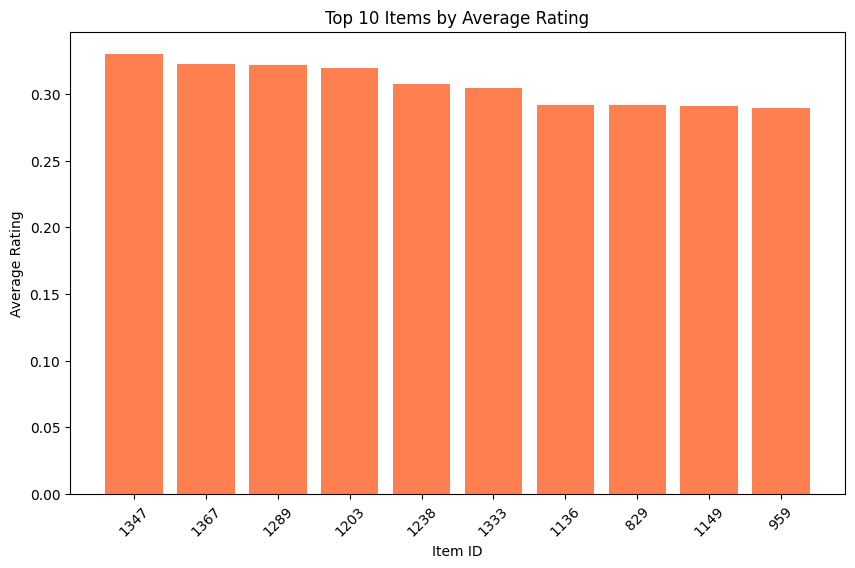

In [10]:
# Explode recommendations to get item_id and rating for all users
exploded_recommendations = user_recommendations.withColumn("recommendation", explode(col("recommendations"))) \
    .select("user_id", col("recommendation.item_id").alias("item_id"), col("recommendation.rating").alias("rating"))

# Calculate average rating for each item
average_ratings = exploded_recommendations.groupBy("item_id").agg(avg("rating").alias("average_rating"))

average_ratings_df = average_ratings.orderBy(col("average_rating").desc()).limit(10).toPandas()

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(average_ratings_df["item_id"].astype(str), average_ratings_df["average_rating"], color="coral")
plt.xlabel("Item ID")
plt.ylabel("Average Rating")
plt.title("Top 10 Items by Average Rating")
plt.xticks(rotation=45)
plt.show()

In [15]:

df_to_save = flattened_recommendations.toPandas()


df_to_save.to_csv("Final_Recommendation.csv", index=False)

print("Successfully saved recommendations to Final_Recommendation.csv!")

Successfully saved recommendations to Final_Recommendation.csv!
